**Preprocessing of OCTA 2D projection maps (ILM_OPL)**  
*( Dividing in Patches + speckle denoising + vesselness filter + normalization + contrast augmentation+ Metrics evaluation)*

Découpage et padding des images: 100%|██████████| 300/300 [00:00<00:00, 1476.89it/s]


Forme du tableau final: (1200, 256, 256)
Premier et dernier ID renommé: 1 1200


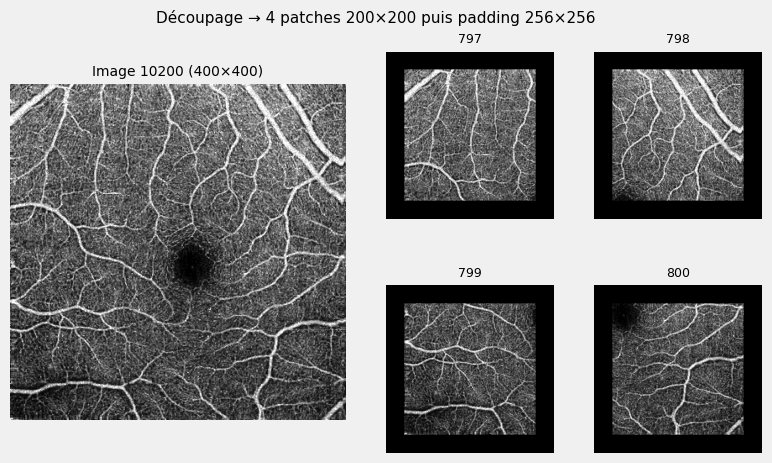

In [14]:
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

# Paramètres principaux
INPUT_DIR = Path(r"C:\Users\hp\OneDrive\Bureau\PRIM\Personal Code\Data\Raw_Data (ILM_OPL)")
start_id = 10001
end_id = 10300
patch_size = 200
target_size = 256

# Choix de l'image à afficher à la fin
DISPLAY_IMG_ID = 10200  # modifier ici pour afficher 10001, 10200, etc.

# Découpage en 4 patches 200x200
def split_into_4_patches_cv2(img: np.ndarray, patch=200):
    # Vérification de la taille attendue de l'image source
    h, w = img.shape
    if (h, w) != (400, 400):
        raise ValueError(f"Taille attendue 400x400, reçu {img.shape}")
    # Découpage des 4 régions
    patches = [
        img[0:patch, 0:patch],
        img[0:patch, w - patch:w],
        img[h - patch:h, 0:patch],
        img[h - patch:h, w - patch:w],
    ]
    return patches

# Padding centré vers 256x256 avec des pixels noirs
def pad_to_square_cv2(arr: np.ndarray, target=256):
    h, w = arr.shape
    if h > target or w > target:
        raise ValueError(f"Patch plus grand que la taille cible: {h}x{w} > {target}")
    dh = target - h
    dw = target - w
    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left
    out = cv2.copyMakeBorder(arr, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=0)
    return out

# Conversion d'un id d'image brute vers les quatre ids renommés 1..1200
def renamed_ids_for_image(raw_img_id: int, start_raw_id: int) -> list[int]:
    # Exemple pour 10001 -> [1,2,3,4] et pour 10002 -> [5,6,7,8]
    offset = raw_img_id - start_raw_id
    first = 4 * offset + 1
    return [first + i for i in range(4)]

# Affichage final avec fond gris, image de base plus à gauche, flèche déplacée
def show_original_and_patches_gray(orig_img: np.ndarray, patch_imgs, raw_img_id: int, titles_right):
    # Figure plus compacte et fond gris
    fig = plt.figure(figsize=(8, 5))
    fig.patch.set_facecolor("#f0f0f0")
    # Grille avec une large colonne à gauche pour pousser l'image vers le bord
    gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[2.0, 1.0, 1.0], height_ratios=[1, 1], wspace=0.18, hspace=0.22)
    # Création des axes
    ax_orig = fig.add_subplot(gs[:, 0])
    ax_r1c1 = fig.add_subplot(gs[0, 1])
    ax_r1c2 = fig.add_subplot(gs[0, 2])
    ax_r2c1 = fig.add_subplot(gs[1, 1])
    ax_r2c2 = fig.add_subplot(gs[1, 2])
    # Ajustement des marges pour coller davantage à gauche
    plt.subplots_adjust(left=0.04, right=0.98, top=0.92, bottom=0.07)
    # Couleur de fond des axes
    for ax in [ax_orig, ax_r1c1, ax_r1c2, ax_r2c1, ax_r2c2]:
        ax.set_facecolor("#ffffff")
    # Image originale
    ax_orig.imshow(orig_img, cmap="gray", vmin=0, vmax=255)
    ax_orig.set_title(f"Image {raw_img_id} (400×400)", fontsize=10)
    ax_orig.set_xticks([])
    ax_orig.set_yticks([])
    for spine in ax_orig.spines.values():
        spine.set_visible(False)
    # Patches
    axs = [ax_r1c1, ax_r1c2, ax_r2c1, ax_r2c2]
    for ax, pimg, ttl in zip(axs, patch_imgs, titles_right):
        ax.imshow(pimg, cmap="gray", vmin=0, vmax=255)
        ax.set_title(str(ttl), fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    # Titre global
    fig.suptitle("Découpage → 4 patches 200×200 puis padding 256×256 ", y=0.98, fontsize=11)
    plt.show()

# Stockage des résultats en mémoire
all_patches = []
all_patch_ids = []
next_patch_id = 1

# Boucle principale avec barre de progression
for img_id in tqdm(range(start_id, end_id + 1), desc="Découpage et padding des images"):
    # Chemin de l'image BMP
    img_path = INPUT_DIR / f"{img_id}.bmp"
    # Lecture et validations
    if not img_path.exists():
        raise FileNotFoundError(f"Introuvable: {img_path}")
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Lecture impossible: {img_path}")
    # Patchs 200x200 puis padding 256x256
    patches = split_into_4_patches_cv2(img, patch=patch_size)
    for p in patches:
        p256 = pad_to_square_cv2(p, target=target_size)
        all_patches.append(p256.astype(np.uint8))
        all_patch_ids.append(next_patch_id)
        next_patch_id += 1

# Tableau final
patches_array = np.stack(all_patches, axis=0)
print("Forme du tableau final:", patches_array.shape)
print("Premier et dernier ID renommé:", all_patch_ids[0], all_patch_ids[-1])

# Visualisation finale paramétrable
if not (start_id <= DISPLAY_IMG_ID <= end_id):
    raise ValueError(f"DISPLAY_IMG_ID doit être compris entre {start_id} et {end_id}")

orig_path = INPUT_DIR / f"{DISPLAY_IMG_ID}.bmp"
orig = cv2.imread(str(orig_path), cv2.IMREAD_GRAYSCALE)
if orig is None:
    raise FileNotFoundError(f"Lecture impossible: {orig_path}")

# Construction des 4 patches de DISPLAY_IMG_ID avec padding pour l'affichage
boxes = [
    (0, 0, patch_size, patch_size),
    (orig.shape[1] - patch_size, 0, orig.shape[1], patch_size),
    (0, orig.shape[0] - patch_size, patch_size, orig.shape[0]),
    (orig.shape[1] - patch_size, orig.shape[0] - patch_size, orig.shape[1], orig.shape[0]),
]
patch_imgs_visu = [pad_to_square_cv2(orig[y0:y1, x0:x1], target=target_size) for (x0, y0, x1, y1) in boxes]

# Calcul automatique des quatre ids renommés correspondant à DISPLAY_IMG_ID
titles_right = renamed_ids_for_image(DISPLAY_IMG_ID, start_id)

# Affichage final
show_original_and_patches_gray(orig_img=orig, patch_imgs=patch_imgs_visu, raw_img_id=DISPLAY_IMG_ID, titles_right=titles_right)

# Le tableau patches_array contient les 1200 patches 256x256 et all_patch_ids contient les identifiants 1 à 1200


**Application d'un filtre médian avec une taille de kernel 3x3 sur les patchs 256**

Découpage et padding (cv2): 100%|███████████| 300/300 [00:00<00:00, 1846.16it/s]


Forme du tableau final: (1200, 256, 256)
Premier et dernier ID renommé: 1 1200
Nombre total d'images disponibles : 1200
Début de l'application du filtre médian...



Application du filtre médian: 100%|██████| 1200/1200 [00:00<00:00, 32867.29it/s]



Filtrage terminé. Affichage d'une image avant et après filtrage.



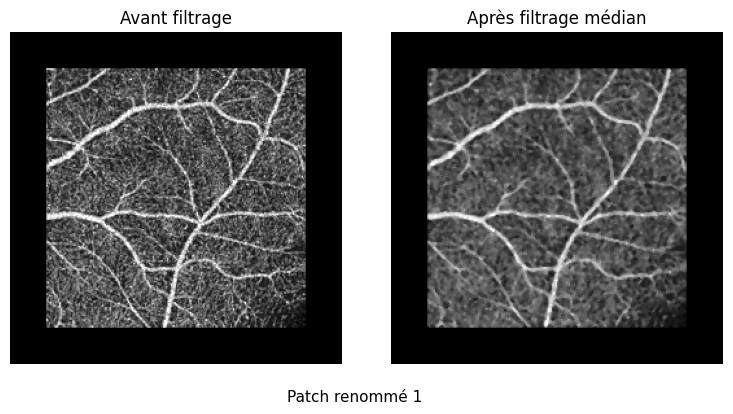

In [19]:
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paramètres principaux
INPUT_DIR = Path(r"C:\Users\hp\OneDrive\Bureau\PRIM\Personal Code\Data\Raw_Data (ILM_OPL)")
start_id = 10001
end_id = 10300
patch_size = 200
target_size = 256

# Fonction de découpe en 4 patches 200x200
def split_into_4_patches_cv2(img: np.ndarray, patch=200):
    # Vérification de la taille attendue de l'image source
    h, w = img.shape
    if (h, w) != (400, 400):
        raise ValueError(f"Taille attendue 400x400, reçu {img.shape}")
    # Découpage des 4 régions
    patches = [
        img[0:patch, 0:patch],
        img[0:patch, w - patch:w],
        img[h - patch:h, 0:patch],
        img[h - patch:h, w - patch:w],
    ]
    return patches

# Fonction de padding centré vers 256x256 avec des pixels noirs
def pad_to_square_cv2(arr: np.ndarray, target=256):
    h, w = arr.shape
    if h > target or w > target:
        raise ValueError(f"Patch plus grand que la taille cible: {h}x{w} > {target}")
    dh = target - h
    dw = target - w
    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left
    out = cv2.copyMakeBorder(arr, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=0)
    return out

# Construction du tableau des patches 256x256 en mémoire
all_patches = []
all_patch_ids = []
next_patch_id = 1

for img_id in tqdm(range(start_id, end_id + 1), desc="Découpage et padding (cv2)", ncols=80):
    img_path = INPUT_DIR / f"{img_id}.bmp"
    if not img_path.exists():
        raise FileNotFoundError(f"Introuvable: {img_path}")
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Lecture impossible: {img_path}")
    patches = split_into_4_patches_cv2(img, patch=patch_size)
    for p in patches:
        p256 = pad_to_square_cv2(p, target=target_size)
        all_patches.append(p256.astype(np.uint8))
        all_patch_ids.append(next_patch_id)
        next_patch_id += 1

patches_array = np.stack(all_patches, axis=0)
print("Forme du tableau final:", patches_array.shape)
print("Premier et dernier ID renommé:", all_patch_ids[0], all_patch_ids[-1])

# Application du filtre médian 3x3 sur les 1200 patches
print(f"Nombre total d'images disponibles : {len(patches_array)}")
if patches_array.dtype != np.uint8:
    print("Conversion en uint8 pour compatibilité avec cv2.medianBlur")
    patches_array = patches_array.astype(np.uint8)

print("Début de l'application du filtre médian...\n")
filtered_imagesmedian = []

for img in tqdm(patches_array, desc="Application du filtre médian", ncols=80):
    filtered = cv2.medianBlur(img, 3)
    filtered_imagesmedian.append(filtered)

filtered_imagesmedian = np.array(filtered_imagesmedian, dtype=np.uint8)
print("\nFiltrage terminé. Affichage d'une image avant et après filtrage.\n")

# Sélection de l'exemple à afficher dans les 1200 patches
index = 0  # modifier entre 0 et 1199 pour afficher un autre patch

# Création d'une figure fond blanc, titres en noir
fig, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor='white')

axes[0].imshow(patches_array[index], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Avant filtrage", color='black', fontsize=12)
axes[0].axis('off')

axes[1].imshow(filtered_imagesmedian[index], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Après filtrage médian", color='black', fontsize=12)
axes[1].axis('off')

# Affichage du nom renommé du patch selon la nouvelle configuration 1..1200
renamed_id = index + 1
fig.text(0.5, 0.02, f"Patch renommé {renamed_id}", ha='center', va='bottom', color='black', fontsize=11)

plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.12, wspace=0.05, hspace=0)
plt.show()


***Application du filtre de Gabor sur les images en sortie du filtrage médian***

Nombre total d'images d'entrée (après médian): 1200
Début du filtrage Gabor pour petits vaisseaux...



Application des filtres de Gabor: 100%|████| 1200/1200 [00:05<00:00, 216.96it/s]



Traitement Gabor terminé. Visualisation d'un exemple...



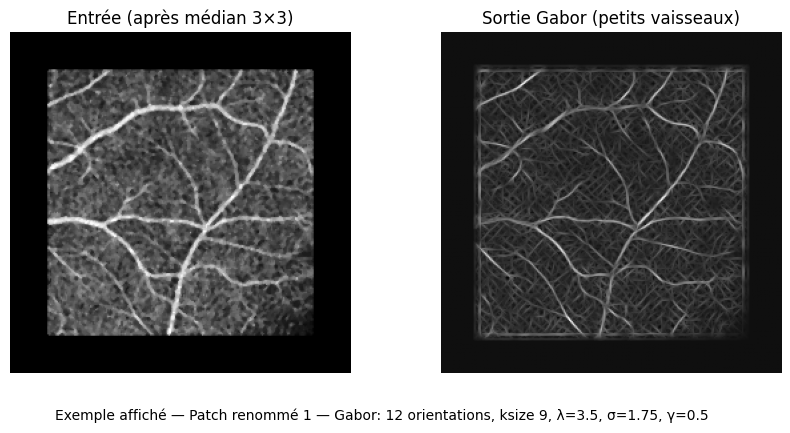

In [21]:
# Détection des petits vaisseaux avec une banque de filtres de Gabor
# Appliquée sur les images déjà filtrées au médian: filtered_imagesmedian (uint8, forme: 1200 x 256 x 256)

# Définition de la fonction d'amélioration par filtres de Gabor
def gabor_vessel_enhancement(img_uint8, thetas, lambd=4.0, sigma=2.0, gamma=0.5):
    # Conversion en float32 pour la convolution
    img = img_uint8.astype(np.float32)
    responses = []
    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(9, 9),
            sigma=sigma,
            theta=theta,
            lambd=lambd,
            gamma=gamma,
            psi=0,
            ktype=cv2.CV_32F
        )
        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        responses.append(filtered)
    # Combinaison par maximum des réponses sur les orientations
    vesselness = np.max(responses, axis=0)
    # Normalisation locale sur 0–255
    vesselness = vesselness - np.min(vesselness)
    vmax = np.max(vesselness)
    if vmax > 0:
        vesselness = vesselness / vmax * 255.0
    return vesselness.astype(np.uint8)

# Vérifications de base sur l'entrée filtered_imagesmedian
print(f"Nombre total d'images d'entrée (après médian): {len(filtered_imagesmedian)}")
if filtered_imagesmedian.dtype != np.uint8:
    print("Conversion en uint8 pour compatibilité avec Gabor")
    filtered_imagesmedian = filtered_imagesmedian.astype(np.uint8)

print("Début du filtrage Gabor pour petits vaisseaux...\n")

# Paramètres Gabor identiques à ton code
thetas = np.linspace(0, np.pi, 12, endpoint=False)
lambd = 3.5
sigma = 1.75
gamma = 0.5

# Application de la banque de filtres de Gabor
filtered_images_gabor = []
for img in tqdm(filtered_imagesmedian, desc="Application des filtres de Gabor", ncols=80):
    vessels = gabor_vessel_enhancement(img, thetas, lambd=lambd, sigma=sigma, gamma=gamma)
    filtered_images_gabor.append(vessels)

filtered_images_gabor = np.array(filtered_images_gabor, dtype=np.uint8)

print("\nTraitement Gabor terminé. Visualisation d'un exemple...\n")

# Visualisation avant/après sur fond blanc, écriture noire
index = 0  # choisir un patch 0..1199

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), facecolor='white')

axes[0].imshow(filtered_imagesmedian[index], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Entrée (après médian 3×3)", color='black', fontsize=12)
axes[0].axis('off')

axes[1].imshow(filtered_images_gabor[index], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Sortie Gabor (petits vaisseaux)", color='black', fontsize=12)
axes[1].axis('off')

# Légende simple avec l'ID renommé 1..1200 correspondant au patch affiché
renamed_id = index + 1
fig.text(0.5, 0.02, f"Exemple affiché — Patch renommé {renamed_id} — Gabor: 12 orientations, ksize 9, λ=3.5, σ=1.75, γ=0.5",
         ha='center', va='bottom', color='black', fontsize=10)

plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.14, wspace=0.06)
plt.show()


Nombre total d'images : 1200
Début de l'amélioration post-Gabor (CLAHE + normalisation)...



Application CLAHE + Normalisation: 100%|██| 1200/1200 [00:00<00:00, 5011.07it/s]



Traitement terminé. Visualisation d'une image exemple...



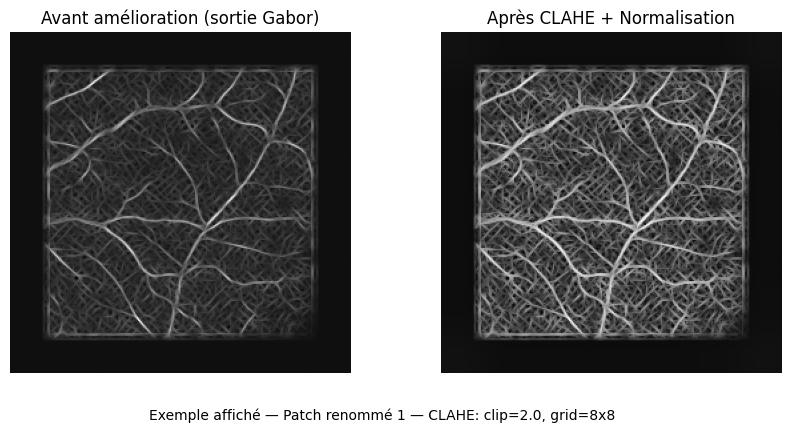

In [23]:
# Amélioration de contraste après Gabor: CLAHE + Normalisation min-max

# Définition de la fonction CLAHE + Normalisation
def enhance_contrast_clahe_norm(img_uint8, clip_limit=2.0, tile_grid_size=(8, 8)):
    # Applique d'abord CLAHE, puis une normalisation min-max en [0, 255]
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_clahe = clahe.apply(img_uint8)
    img_norm = cv2.normalize(img_clahe, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    return img_norm.astype(np.uint8)

# Vérification des données d'entrée: on travaille sur la sortie Gabor après médian
print(f"Nombre total d'images : {len(filtered_images_gabor)}")
if filtered_images_gabor.dtype != np.uint8:
    print("Conversion en uint8 pour compatibilité avec CLAHE/normalize")
    filtered_images_gabor = filtered_images_gabor.astype(np.uint8)

print("Début de l'amélioration post-Gabor (CLAHE + normalisation)...\n")

enhanced_images_gabor = []

# Application de CLAHE + Normalisation à chaque image Gabor
for img in tqdm(filtered_images_gabor, desc="Application CLAHE + Normalisation", ncols=80):
    enhanced = enhance_contrast_clahe_norm(img, clip_limit=2.0, tile_grid_size=(8, 8))
    enhanced_images_gabor.append(enhanced)

enhanced_images_gabor = np.array(enhanced_images_gabor, dtype=np.uint8)

print("\nTraitement terminé. Visualisation d'une image exemple...\n")

# Visualisation d'un patch avant/après (fond blanc, écriture noire)
index = 0  # modifier entre 0 et 1199 pour afficher un autre patch

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), facecolor='white')

axes[0].imshow(filtered_images_gabor[index], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Avant amélioration (sortie Gabor)", color='black', fontsize=12)
axes[0].axis('off')

axes[1].imshow(enhanced_images_gabor[index], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Après CLAHE + Normalisation", color='black', fontsize=12)
axes[1].axis('off')

# Légende indiquant le nom renommé du patch selon la configuration 1..1200
renamed_id = index + 1
fig.text(0.5, 0.02, f"Exemple affiché — Patch renommé {renamed_id} — CLAHE: clip=2.0, grid=8x8", ha='center', va='bottom', color='black', fontsize=10)

plt.subplots_adjust(left=0.05, right=0.98, top=0.95, bottom=0.14, wspace=0.06)
plt.show()
